In [ ]:
#one_way anova
from scipy.stats import f_oneway

# Enter exam scores for each group
group1 = [85, 86, 88, 75, 78, 94, 98, 79, 71, 80]
group2 = [91, 92, 93, 85, 87, 84, 82, 88, 95, 96]
group3 = [79, 78, 88, 94, 92, 85, 83, 85, 82, 81]

# Perform one-way ANOVA
f_statistic, p_value = f_oneway(group1, group2, group3)

# Display the results
print(f"F-statistic: {f_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

F-statistic: 2.3575
P-value: 0.1138


In [ ]:
#Two_way anova
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Create data
df = pd.DataFrame({'water': np.repeat(['daily', 'weekly'], 15),
                   'sun': np.tile(np.repeat(['low', 'med', 'high'], 5), 2),
                   'height': [6, 6, 6, 5, 6, 5, 5, 6, 4, 5,
                              6, 6, 7, 8, 7, 3, 4, 4, 4, 5,
                              4, 4, 4, 4, 4, 5, 6, 6, 7, 8]})
# Perform two-way ANOVA
model = ols('height ~ C(water) + C(sun) + C(water):C(sun)', data=df).fit()
anova_result = sm.stats.anova_lm(model, typ=2)

# Display the result
print(anova_result)

                    sum_sq    df        F    PR(>F)
C(water)          8.533333   1.0  16.0000  0.000527
C(sun)           24.866667   2.0  23.3125  0.000002
C(water):C(sun)   2.466667   2.0   2.3125  0.120667
Residual         12.800000  24.0      NaN       NaN


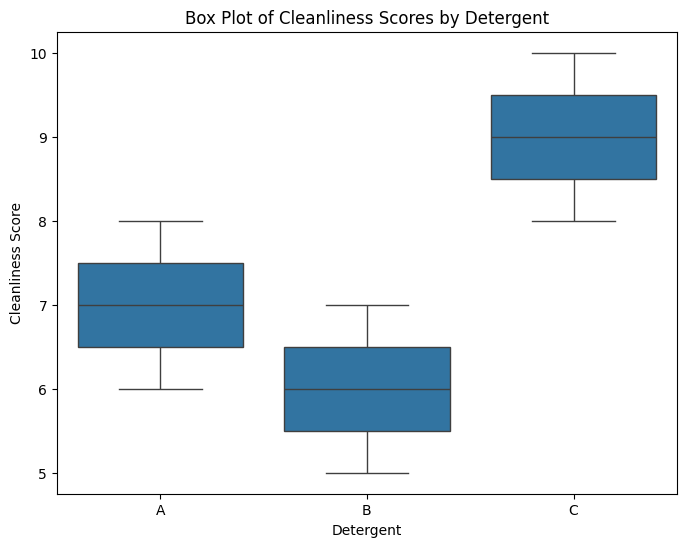

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create the data
data = {
    'Detergent': ['A', 'A', 'A', 'B', 'B', 'B', 'C', 'C', 'C'],
    'Cleanliness_Score': [6, 7, 8, 5, 6, 7, 8, 9, 10]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Create a box plot for Cleanliness Score by Detergent
plt.figure(figsize=(8, 6))
sns.boxplot(x='Detergent', y='Cleanliness_Score', data=df)
plt.title('Box Plot of Cleanliness Scores by Detergent')
plt.ylabel('Cleanliness Score')
plt.xlabel('Detergent')
plt.show()

DataFrame:
   Participant    Technique  StressLevel
0           P1  Technique 1           45
1           P1  Technique 2           42
2           P1  Technique 3           39
3           P2  Technique 1           55
4           P2  Technique 2           50
5           P2  Technique 3           47
6           P3  Technique 1           43
7           P3  Technique 2           40
8           P3  Technique 3           35
9           P4  Technique 1           58
10          P4  Technique 2           53
11          P4  Technique 3           50

ANOVA Results:
                 Anova
          F Value  Num DF Den DF Pr > F
---------------------------------------
Technique 101.4000 2.0000 6.0000 0.0000



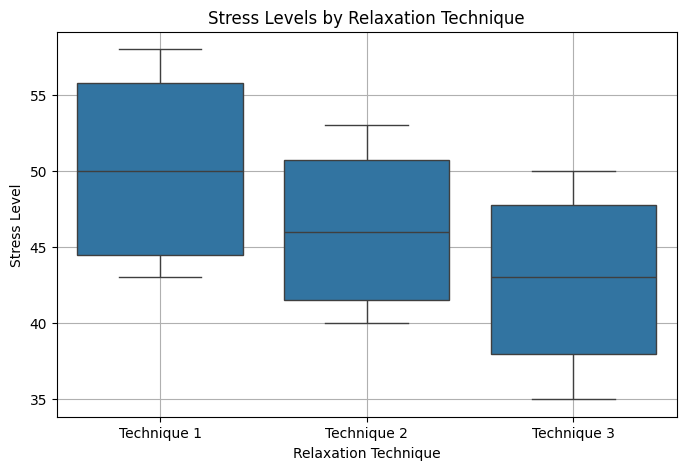

In [ ]:
#repeated_measure anova
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.anova import AnovaRM

# Data: Stress levels of 4 participants under 3 relaxation techniques
data = {
    'Participant': ['P1', 'P1', 'P1',  # Participant 1
                    'P2', 'P2', 'P2',  # Participant 2
                    'P3', 'P3', 'P3',  # Participant 3
                    'P4', 'P4', 'P4'],  # Participant 4
    'Technique': ['Technique 1', 'Technique 2', 'Technique 3',  # Techniques for each participant
                  'Technique 1', 'Technique 2', 'Technique 3',
                  'Technique 1', 'Technique 2', 'Technique 3',
                  'Technique 1', 'Technique 2', 'Technique 3'],
    'StressLevel': [45, 42, 39,  # Stress levels for P1
                    55, 50, 47,  # Stress levels for P2
                    43, 40, 35,  # Stress levels for P3
                    58, 53, 50]  # Stress levels for P4
}

# Create a DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
print("DataFrame:")
print(df)

# Perform Repeated Measures ANOVA
anova_results = AnovaRM(df, 'StressLevel', 'Participant', within=['Technique']).fit()

# Display results
print("\nANOVA Results:")
print(anova_results)

# Box Plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Technique', y='StressLevel', data=df)
plt.title('Stress Levels by Relaxation Technique')
plt.xlabel('Relaxation Technique')
plt.ylabel('Stress Level')
plt.grid(True)
plt.show()


In [ ]:
#scheffe's test
import numpy as np

# Data for each diet
means = {'A': 10, 'B': 15, 'C': 20}
sample_size = 15
ms_within = 12  # Mean Square Within, assumed from ANOVA
k = len(means)  # Number of groups (diets)

# F-critical value from ANOVA (given in the problem)
f_critical = 3.2

# Step 1: Calculate Scheffé’s test critical value
scheffe_critical_value = (k - 1) * f_critical
print(f"Scheffé’s critical value: {scheffe_critical_value}")

# Step 2: Calculate squared mean differences and adjusted values
mean_diffs = {}
for (diet1, mean1), (diet2, mean2) in [
    (('A', means['A']), ('B', means['B'])),
    (('A', means['A']), ('C', means['C'])),
    (('B', means['B']), ('C', means['C']))
]:
    squared_diff = (mean2 - mean1) ** 2
    adjusted_diff = squared_diff / (ms_within / sample_size)
    mean_diffs[f"{diet1} vs {diet2}"] = adjusted_diff
    print(f"Adjusted mean square difference for {diet1} vs {diet2}: {adjusted_diff}")

# Step 3: Determine which differences are significant
print("\nSignificance Results:")
for pair, adjusted_diff in mean_diffs.items():
    if adjusted_diff > scheffe_critical_value:
        print(f"{pair} shows a significant difference (adjusted value {adjusted_diff} > Scheffé critical {scheffe_critical_value})")
    else:
        print(f"{pair} does not show a significant difference (adjusted value {adjusted_diff} <= Scheffé critical {scheffe_critical_value})")

Scheffé’s critical value: 6.4
Adjusted mean square difference for A vs B: 31.25
Adjusted mean square difference for A vs C: 125.0
Adjusted mean square difference for B vs C: 31.25

Significance Results:
A vs B shows a significant difference (adjusted value 31.25 > Scheffé critical 6.4)
A vs C shows a significant difference (adjusted value 125.0 > Scheffé critical 6.4)
B vs C shows a significant difference (adjusted value 31.25 > Scheffé critical 6.4)
